In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns

%matplotlib inline

# Load the CLEAN dataset saved by notebook 01
df = pd.read_csv("../data/mexico-real-estate-clean.csv")

print("✅ Clean data loaded!")
print("Shape:", df.shape)
df.head()

✅ Clean data loaded!
Shape: (1978, 6)


,property_type,state,lat,lon,area_m2,price_usd
0,house,Estado de México,19.560181,-99.233528,150,67965.56
1,house,Nuevo León,25.688436,-100.198807,186,63223.78
2,apartment,Guerrero,16.767704,-99.764383,82,84298.37
3,apartment,Guerrero,16.829782,-99.911012,150,94308.80
4,house,Yucatán,21.052583,-89.538639,205,105191.37


In [2]:
print("=== DATASET OVERVIEW ===")
print(f"Total properties: {len(df):,}")
print(f"\nProperty types:\n{df['property_type'].value_counts()}")
print(f"\nTop 10 states:\n{df['state'].value_counts().head(10)}")
print(f"\nPrice statistics (USD):")
print(df["price_usd"].describe().apply(lambda x: f"${x:,.2f}"))
print(f"\nArea statistics (m²):")
print(df["area_m2"].describe())

=== DATASET OVERVIEW ===
Total properties: 1,978

Property types:
property_type
house        1540
apartment     438
Name: count, dtype: int64

Top 10 states:
state
Distrito Federal                   203
Yucatán                            139
Estado de México                   123
Morelos                            112
Puebla                              91
Veracruz de Ignacio de la Llave     91
Querétaro                           90
Nuevo León                          57
San Luis Potosí                     45
Jalisco                             41
Name: count, dtype: int64

Price statistics (USD):
count      $1,978.00
mean     $116,720.36
std       $66,451.07
min       $32,947.37
25%       $65,789.47
50%       $99,601.06
75%      $152,224.26
max      $326,733.66
Name: price_usd, dtype: str

Area statistics (m²):
count    1978.000000
mean      172.255814
std        80.003119
min        60.000000
25%       104.000000
50%       160.000000
75%       221.750000
max       385.000000
Name: ar

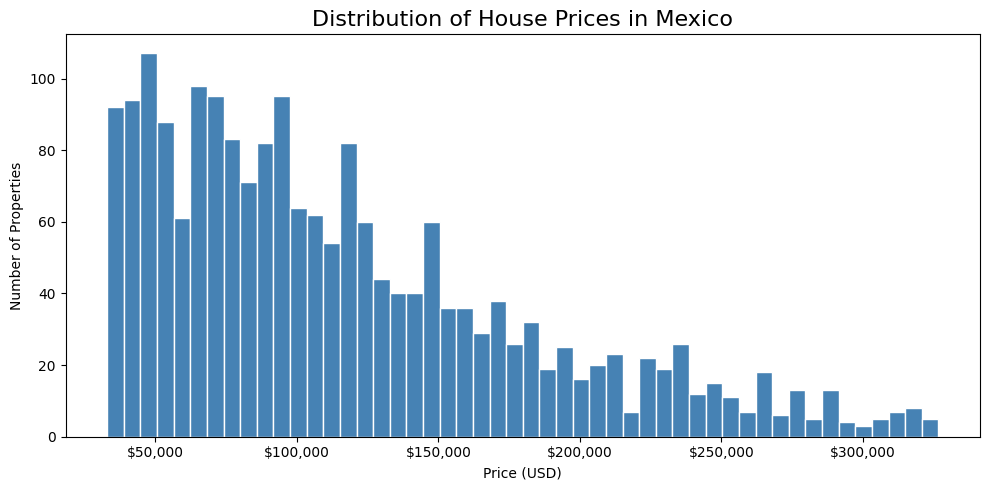

✅ Graph saved!


In [3]:
plt.figure(figsize=(10, 5))
plt.hist(df["price_usd"], bins=50, color="steelblue", edgecolor="white")
plt.title("Distribution of House Prices in Mexico", fontsize=16)
plt.xlabel("Price (USD)")
plt.ylabel("Number of Properties")
plt.gca().xaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, _: f"${x:,.0f}")
)
plt.tight_layout()
plt.savefig("../notebooks/price_distribution.png")
plt.show()
print("✅ Graph saved!")

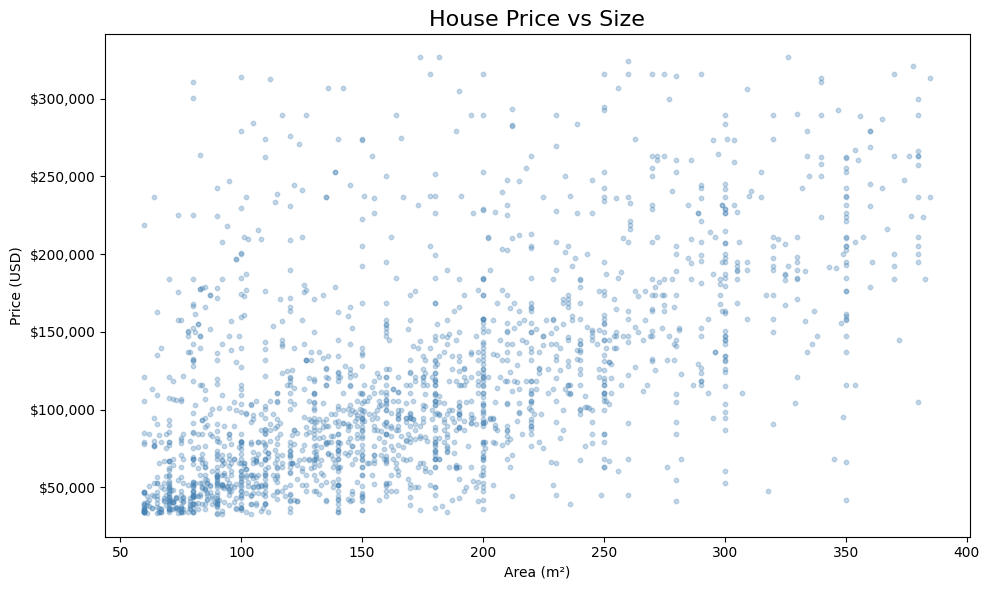

In [4]:
plt.figure(figsize=(10, 6))
plt.scatter(df["area_m2"], df["price_usd"], 
            alpha=0.3, color="steelblue", s=10)
plt.title("House Price vs Size", fontsize=16)
plt.xlabel("Area (m²)")
plt.ylabel("Price (USD)")
plt.gca().yaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, _: f"${x:,.0f}")
)
plt.tight_layout()
plt.savefig("../notebooks/price_vs_area.png")
plt.show()

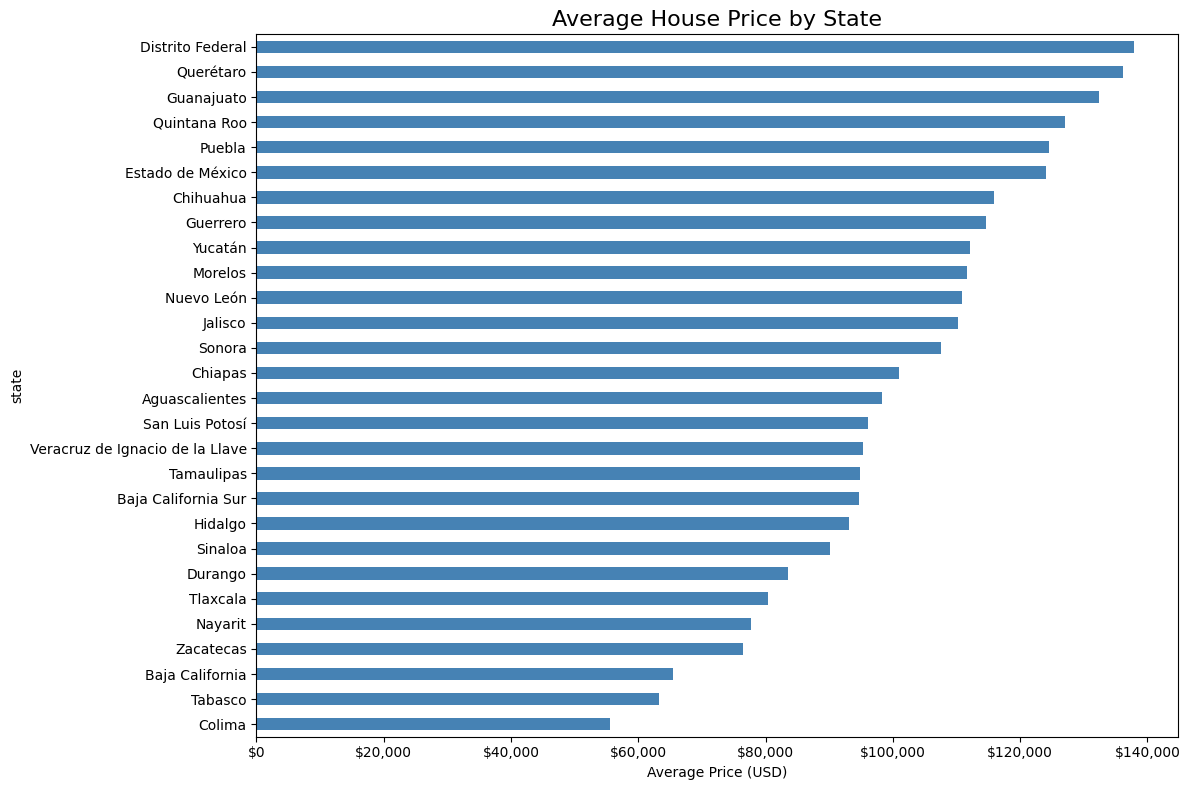

In [5]:
# Calculate average price per state
state_prices = (
    df.groupby("state")["price_usd"]
    .mean()
    .sort_values(ascending=True)
)

plt.figure(figsize=(12, 8))
state_prices.plot(kind="barh", color="steelblue")
plt.title("Average House Price by State", fontsize=16)
plt.xlabel("Average Price (USD)")
plt.gca().xaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, _: f"${x:,.0f}")
)
plt.tight_layout()
plt.savefig("../notebooks/price_by_state.png")
plt.show()

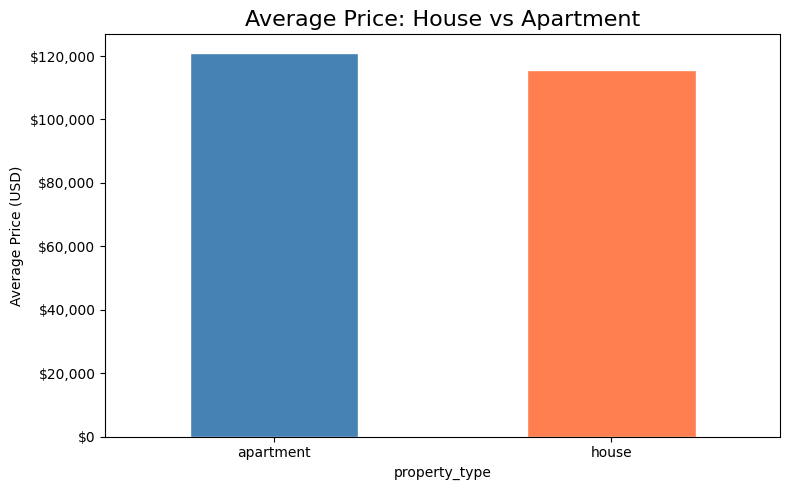

In [6]:
plt.figure(figsize=(8, 5))
df.groupby("property_type")["price_usd"].mean().plot(
    kind="bar", color=["steelblue", "coral"], edgecolor="white"
)
plt.title("Average Price: House vs Apartment", fontsize=16)
plt.ylabel("Average Price (USD)")
plt.xticks(rotation=0)
plt.gca().yaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, _: f"${x:,.0f}")
)
plt.tight_layout()
plt.savefig("../notebooks/house_vs_apartment.png")
plt.show()

In [7]:
# How strongly does area relate to price?
correlation = df["area_m2"].corr(df["price_usd"])
print(f"Correlation between area and price: {correlation:.4f}")
print()
if correlation > 0.5:
    print("✅ STRONG positive relationship — bigger area = higher price!")
elif correlation > 0.3:
    print("⚠️ MODERATE relationship — area somewhat predicts price")
else:
    print("❌ WEAK relationship — area alone may not predict price well")
    

Correlation between area and price: 0.5918

✅ STRONG positive relationship — bigger area = higher price!
